<div style="text-align:center;">

# Modelo: XGBoost Classifier
### *Clasificación de la Rotación de Empleados (IBM HR Analytics)*

---
**Universidad de Antioquia — Instituto de Matemáticas**  
*Analítica de Datos — Laboratorio 5*

</div>

---

## Contenido de este notebook

Este notebook desarrolla — de forma autocontenida — los siguientes puntos del Laboratorio 5 para el algoritmo **XGBoost**:

3. **Preparación de los Datos** — separación X / y, partición train/test estratificada, construcción del `Pipeline` con codificación de variables categóricas y escalamiento.
4. **Entrenamiento del modelo** dentro del `Pipeline`.
5. **Validación cruzada estratificada** (`StratifiedKFold`, k = 5) con métricas reportadas como $\mu \pm \sigma$ y visualización del comportamiento entre folds.

> Las decisiones de preprocesamiento fueron tomadas en el notebook `0.Exploracion_Inicial.ipynb` y aquí se replican estrictamente, garantizando comparabilidad con los demás modelos.

### Descripción del algoritmo

**XGBoost** (Extreme Gradient Boosting) construye un ensamble **secuencial** de árboles donde cada nuevo árbol corrige los errores residuales del ensamble anterior, optimizando la pérdida mediante **gradient boosting** con regularización L1/L2. Es uno de los algoritmos **más competitivos** en problemas tabulares y suele ganar la comparación contra Random Forest en datasets de tamaño medio.

### Tratamiento del desbalance

XGBoost no acepta `class_weight`. Su mecanismo equivalente es `scale_pos_weight = n_neg / n_pos`, que escala el gradiente de la clase positiva en la función de pérdida — el resultado es matemáticamente análogo a reponderar la entropía cruzada.


---
## 1. Importación de librerías y configuración

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# Preprocesamiento y pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelo
from xgboost import XGBClassifier

# Validación cruzada y métricas
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, cross_val_predict)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)

# ── Estilo visual unificado ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titleweight"  : "bold",
    "axes.titlesize"    : 12,
    "axes.labelsize"    : 10,
    "font.size"         : 10,
    "legend.frameon"    : False,
})

COLOR_YES, COLOR_NO = "#e74c3c", "#3498db"
COLOR_MODELO = "#2c3e50"      # color principal del modelo

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## 2. Carga y preparación del conjunto de datos

In [2]:
DATA_PATH = Path.cwd().parent.parent / "data" / "raw" / "dataset_clasificacion.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

# ── Eliminamos columnas sin información (constantes / identificador) ─────
COLS_DESCARTAR = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df = df.drop(columns=COLS_DESCARTAR)

print(f"Dimensiones tras descartar columnas inútiles: {df.shape}")
df.head(3)

Dimensiones tras descartar columnas inútiles: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0


---
## 3. Preparación de los Datos

### 3.1 Separación de variables predictoras (X) y objetivo (y)

Se codifica el target de manera explícita: $\text{Yes} \mapsto 1,\ \text{No} \mapsto 0$, con la clase positiva siendo la **renuncia** (que es la que interesa detectar).


In [3]:
y = (df["Attrition"] == "Yes").astype(int)
X = df.drop(columns=["Attrition"])

print(f"X : {X.shape[0]:,} observaciones × {X.shape[1]} features")
print(f"y : binaria — Yes(1) = {y.sum()}  |  No(0) = {(y==0).sum()}")
print(f"    Proporción de la clase positiva: {y.mean()*100:.2f} %")

X : 1,470 observaciones × 30 features
y : binaria — Yes(1) = 237  |  No(0) = 1233
    Proporción de la clase positiva: 16.12 %


### 3.2 Identificación del tipo de variables

Se replican las decisiones tomadas en `0.Exploracion_Inicial.ipynb`:

| Grupo | Tratamiento |
|:---|:---|
| **Nominales** (7) | One-Hot Encoding con `drop="first"` |
| **Numéricas + Ordinales** (23) | Estandarización con `StandardScaler` |


In [4]:
COLS_NOMINALES = ["BusinessTravel", "Department", "EducationField",
                  "Gender", "JobRole", "MaritalStatus", "OverTime"]

COLS_NUMERICAS = [c for c in X.columns if c not in COLS_NOMINALES]

print(f"Nominales ({len(COLS_NOMINALES)}) : {COLS_NOMINALES}")
print(f"\nNuméricas ({len(COLS_NUMERICAS)}) : {COLS_NUMERICAS}")

Nominales (7) : ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numéricas (23) : ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


### 3.3 Partición Train / Test estratificada

- Proporción **70 / 30** (entrenamiento / prueba).
- Se usa **estratificación por la variable objetivo** (`stratify=y`) para preservar la proporción $16.1\,/\,83.9$ en ambos subconjuntos.
- `random_state=42` para reproducibilidad.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]:,} obs.  | Yes = {y_train.mean()*100:.2f} %")
print(f"Test  : {X_test.shape[0]:,} obs.  | Yes = {y_test.mean()*100:.2f} %")

Train : 1,029 obs.  | Yes = 16.13 %
Test  : 441 obs.  | Yes = 16.10 %


### 3.4 Construcción del Pipeline de preprocesamiento

El `ColumnTransformer` aplica **One-Hot Encoding** a las nominales y **estandarización** a las numéricas. Al estar **dentro del `Pipeline`**, ambas transformaciones son ajustadas únicamente sobre cada fold de entrenamiento durante la validación cruzada, evitando cualquier **fuga de información** desde los folds de validación.

> **Importante**: tanto la codificación como el escalado deben aprenderse exclusivamente sobre los datos de entrenamiento de cada fold. El uso del `Pipeline` garantiza esta propiedad de manera automática.


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), COLS_NOMINALES),
        ("num", StandardScaler(), COLS_NUMERICAS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

---
## 4. Construcción y entrenamiento del modelo

### 4.1 Instanciación dentro del `Pipeline`

El modelo se integra como segundo paso del `Pipeline`. Toda evaluación posterior se hace sobre el `Pipeline` completo (preprocesamiento + clasificador), de modo que el escalado y la codificación se ajustan **en cada fold** sobre los datos de entrenamiento únicamente.


In [7]:
# scale_pos_weight equivale a class_weight="balanced" para XGBoost
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
print(f"scale_pos_weight = n_neg / n_pos = {n_neg} / {n_pos} = {n_neg/n_pos:.4f}")

modelo = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("clf", XGBClassifier(scale_pos_weight=n_neg/n_pos, n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42, eval_metric="logloss", verbosity=0)),
])
modelo

scale_pos_weight = n_neg / n_pos = 863 / 166 = 5.1988


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

### 4.2 Entrenamiento sobre el conjunto de entrenamiento completo

In [8]:
modelo.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


---
## 5. Validación Cruzada Estratificada (k = 5)

### 5.1 Diseño del experimento

- **`StratifiedKFold`** con `n_splits=5`, `shuffle=True`, `random_state=42` — preserva la proporción de clases en cada fold.
- Se evalúan **cinco métricas** simultáneamente: `accuracy`, `precision`, `recall`, `f1` y `roc_auc`.
- El `Pipeline` completo se reajusta en cada fold ⇒ no hay fuga de información del preprocesamiento.
- Los resultados se reportan como $\mu \pm \sigma$ sobre los 5 folds.


In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy" : "accuracy",
    "precision": "precision",
    "recall"   : "recall",
    "f1"       : "f1",
    "roc_auc"  : "roc_auc",
}

cv_results = cross_validate(
    modelo, X_train, y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
)

print("Validación cruzada finalizada.")
print(f"Número de folds: {skf.get_n_splits()}")

Validación cruzada finalizada.
Número de folds: 5


### 5.2 Resultados consolidados — $\mu \pm \sigma$

In [10]:
def resumen_cv(cv_results, metricas):
    filas = []
    for m in metricas:
        train = cv_results[f"train_{m}"]
        test  = cv_results[f"test_{m}"]
        filas.append({
            "Métrica"          : m.upper(),
            "Train  μ"         : train.mean(),
            "Train  σ"         : train.std(),
            "Validación  μ"    : test.mean(),
            "Validación  σ"    : test.std(),
            "Gap (Train − Val)": train.mean() - test.mean(),
        })
    return pd.DataFrame(filas).set_index("Métrica").round(4)

tabla_cv = resumen_cv(cv_results, ["accuracy", "precision", "recall", "f1", "roc_auc"])
tabla_cv

,Train μ,Train σ,Validación μ,Validación σ,Gap (Train − Val)
Métrica,,,,,
ACCURACY,1.0,0.0,0.8756,0.0129,0.1244
PRECISION,1.0,0.0,0.6683,0.0603,0.3317
RECALL,1.0,0.0,0.4583,0.0584,0.5417
F1,1.0,0.0,0.5419,0.0539,0.4581
ROC_AUC,1.0,0.0,0.8124,0.0383,0.1876


In [11]:
# Reporte en formato μ ± σ (limpio para presentación)
print("─" * 56)
print(f"  {'Métrica':<12} {'Validación (μ ± σ)':>22}  {'Train (μ ± σ)':>18}")
print("─" * 56)
for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    v = cv_results[f"test_{m}"]
    t = cv_results[f"train_{m}"]
    print(f"  {m.upper():<12} {v.mean():>8.4f} ± {v.std():.4f}     {t.mean():>6.4f} ± {t.std():.4f}")
print("─" * 56)

────────────────────────────────────────────────────────
  Métrica          Validación (μ ± σ)       Train (μ ± σ)
────────────────────────────────────────────────────────
  ACCURACY       0.8756 ± 0.0129     1.0000 ± 0.0000
  PRECISION      0.6683 ± 0.0603     1.0000 ± 0.0000
  RECALL         0.4583 ± 0.0584     1.0000 ± 0.0000
  F1             0.5419 ± 0.0539     1.0000 ± 0.0000
  ROC_AUC        0.8124 ± 0.0383     1.0000 ± 0.0000
────────────────────────────────────────────────────────


### 5.3 Visualización 1 — Distribución de métricas por fold

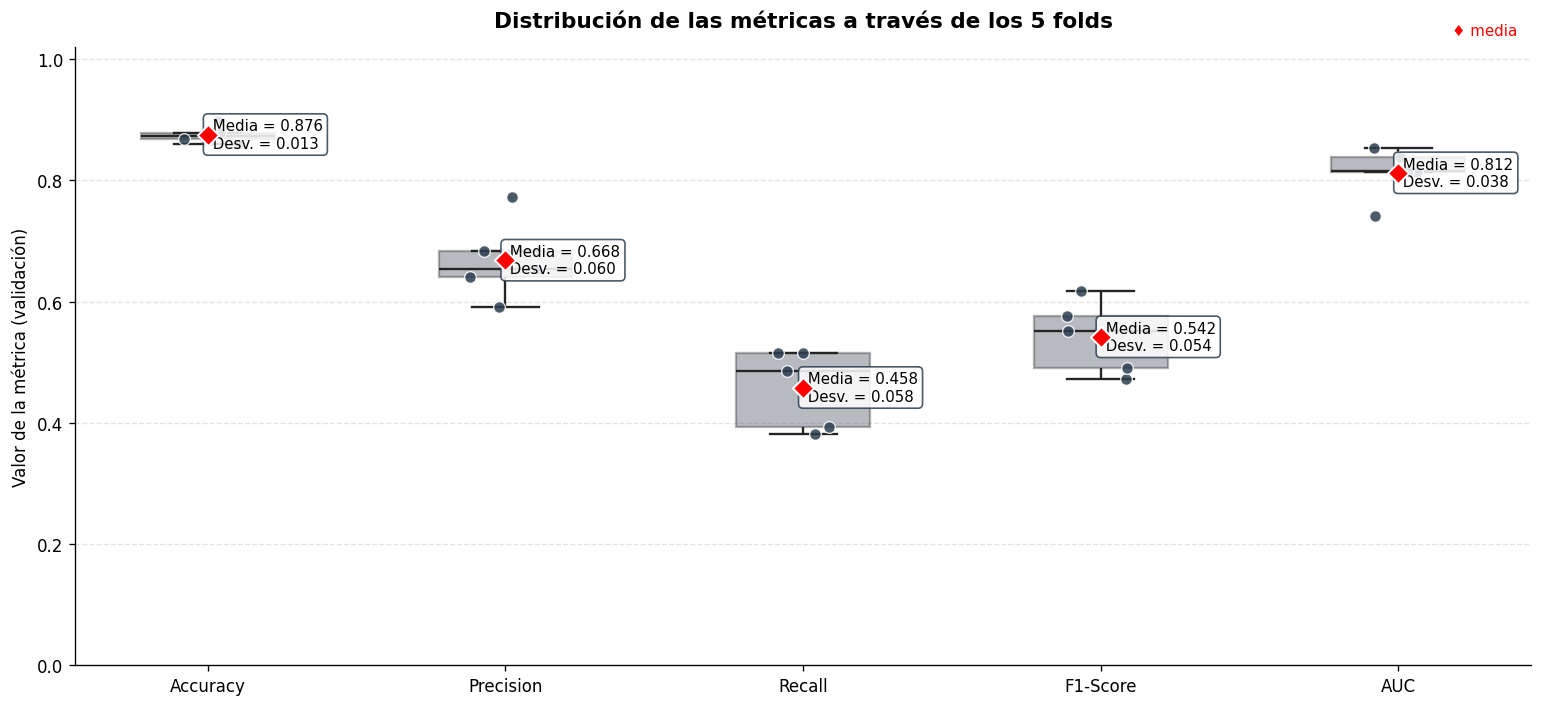

In [12]:
metricas = ["accuracy", "precision", "recall", "f1", "roc_auc"]
nombres  = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]

# DataFrame "tidy" para seaborn
data_tidy = []
for m, nom in zip(metricas, nombres):
    for fold, val in enumerate(cv_results[f"test_{m}"], start=1):
        data_tidy.append({"Métrica": nom, "Fold": fold, "Valor": val})
df_tidy = pd.DataFrame(data_tidy)

fig, ax = plt.subplots(figsize=(13, 6))

sns.boxplot(data=df_tidy, x="Métrica", y="Valor",
            color=COLOR_MODELO, width=0.45, fliersize=0, ax=ax, linewidth=1.4,
            boxprops=dict(alpha=0.35))
sns.stripplot(data=df_tidy, x="Métrica", y="Valor",
              color=COLOR_MODELO, size=7, jitter=0.12, alpha=0.85,
              edgecolor="white", linewidth=0.8, ax=ax)

# Anotación de la media en cada métrica
for i, m in enumerate(metricas):
    media = cv_results[f"test_{m}"].mean()
    std   = cv_results[f"test_{m}"].std()
    ax.text(i, media, f" Media = {media:.3f}\n Desv. = {std:.3f}",
            fontsize=9, ha="left", va="center",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white", edgecolor=COLOR_MODELO, alpha=0.85))
    ax.scatter(i, media, color="red", s=80, zorder=5,
               marker="D", edgecolor="white", linewidth=1.2)

ax.set_ylim(0, 1.02)
ax.set_ylabel("Valor de la métrica (validación)")
ax.set_xlabel("")
ax.set_title("Distribución de las métricas a través de los 5 folds",
             fontsize=13, pad=12)
ax.grid(axis="y", ls="--", alpha=0.35)

ax.text(0.99, 1.02, "♦ media",
        transform=ax.transAxes, ha="right", fontsize=9, color="red")

plt.tight_layout()
plt.show()

### 5.4 Visualización 2 — Comparación Train vs. Validación (diagnóstico de sobreajuste)

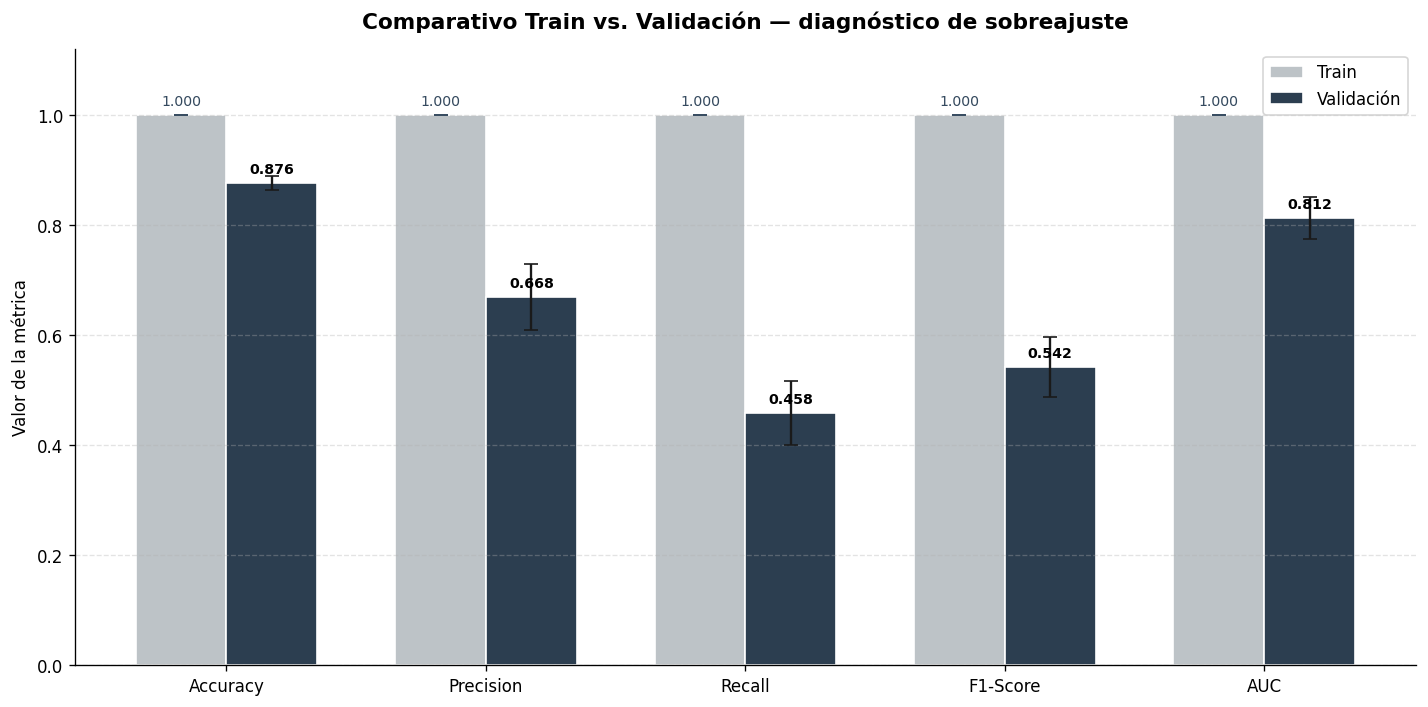

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metricas))
ancho = 0.35

medias_train = [cv_results[f"train_{m}"].mean() for m in metricas]
stds_train   = [cv_results[f"train_{m}"].std()  for m in metricas]
medias_val   = [cv_results[f"test_{m}"].mean()  for m in metricas]
stds_val     = [cv_results[f"test_{m}"].std()   for m in metricas]

bars_t = ax.bar(x - ancho/2, medias_train, ancho, yerr=stds_train, capsize=4,
                color="#bdc3c7", edgecolor="white", label="Train",
                error_kw=dict(elinewidth=1.4, ecolor="#34495e"))
bars_v = ax.bar(x + ancho/2, medias_val, ancho, yerr=stds_val, capsize=4,
                color=COLOR_MODELO, edgecolor="white", label="Validación",
                error_kw=dict(elinewidth=1.4, ecolor="#1a1a1a"))

# Etiquetas numéricas
for b, val in zip(bars_t, medias_train):
    ax.text(b.get_x() + b.get_width()/2, val + 0.018,
            f"{val:.3f}", ha="center", fontsize=8.5, color="#34495e")
for b, val in zip(bars_v, medias_val):
    ax.text(b.get_x() + b.get_width()/2, val + 0.018,
            f"{val:.3f}", ha="center", fontsize=8.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(nombres)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Valor de la métrica")
ax.set_title("Comparativo Train vs. Validación — diagnóstico de sobreajuste",
             fontsize=13, pad=12)
ax.legend(loc="upper right", frameon=True, fancybox=True)
ax.grid(axis="y", ls="--", alpha=0.35)
plt.tight_layout()
plt.show()

### 5.5 Visualización 3 — Curva ROC promedio sobre los 5 folds

Promediamos las curvas ROC obtenidas en cada fold de validación e indicamos la franja $\pm 1\sigma$ del TPR para cuantificar la **estabilidad** del clasificador entre folds.


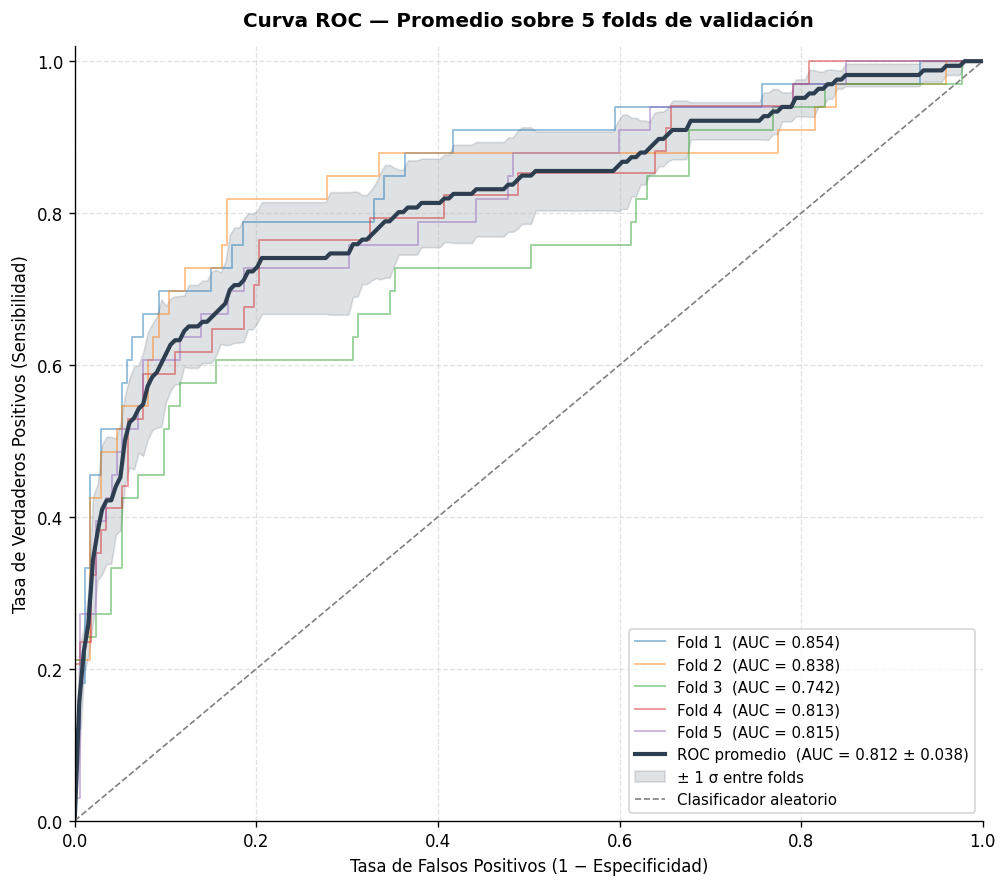

In [14]:
mean_fpr = np.linspace(0, 1, 200)
tprs, aucs = [], []

fig, ax = plt.subplots(figsize=(8.5, 7.5))

for i, (idx_tr, idx_va) in enumerate(skf.split(X_train, y_train), start=1):
    Xtr, Xva = X_train.iloc[idx_tr], X_train.iloc[idx_va]
    ytr, yva = y_train.iloc[idx_tr], y_train.iloc[idx_va]

    modelo.fit(Xtr, ytr)
    y_score = modelo.predict_proba(Xva)[:, 1]
    fpr, tpr, _ = roc_curve(yva, y_score)
    auc_fold = roc_auc_score(yva, y_score)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(auc_fold)

    ax.plot(fpr, tpr, lw=1.2, alpha=0.45,
            label=f"Fold {i}  (AUC = {auc_fold:.3f})")

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
std_tpr   = np.std(tprs, axis=0)
mean_auc  = np.mean(aucs)
std_auc   = np.std(aucs)

ax.plot(mean_fpr, mean_tpr, color=COLOR_MODELO, lw=2.5,
        label=f"ROC promedio  (AUC = {mean_auc:.3f} ± {std_auc:.3f})")
ax.fill_between(mean_fpr, np.maximum(mean_tpr - std_tpr, 0),
                np.minimum(mean_tpr + std_tpr, 1),
                color=COLOR_MODELO, alpha=0.15,
                label="± 1 σ entre folds")

ax.plot([0,1], [0,1], ls="--", color="gray", lw=1, label="Clasificador aleatorio")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Tasa de Falsos Positivos (1 − Especificidad)")
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
ax.set_title("Curva ROC — Promedio sobre 5 folds de validación", pad=12)
ax.legend(loc="lower right", fontsize=9, frameon=True, fancybox=True)
ax.grid(ls="--", alpha=0.35)
plt.tight_layout()
plt.show()

# Re-ajustamos el modelo sobre todo el train para dejarlo entrenado al final
modelo.fit(X_train, y_train);

### 5.6 Visualización 4 — Matriz de Confusión (predicciones out-of-fold)

La matriz se calcula a partir de **`cross_val_predict`**, que agrega las predicciones de cada observación del conjunto de entrenamiento **cuando ésta caía en el fold de validación**. De esta manera, cada observación se predice una sola vez con un modelo que **no la vio durante su entrenamiento** — la matriz refleja el desempeño esperado sobre datos no vistos.

> Es la misma información que entregan las métricas $\mu \pm \sigma$ de la sección 5.2, pero desagregada en los cuatro tipos de error/acierto del clasificador binario.


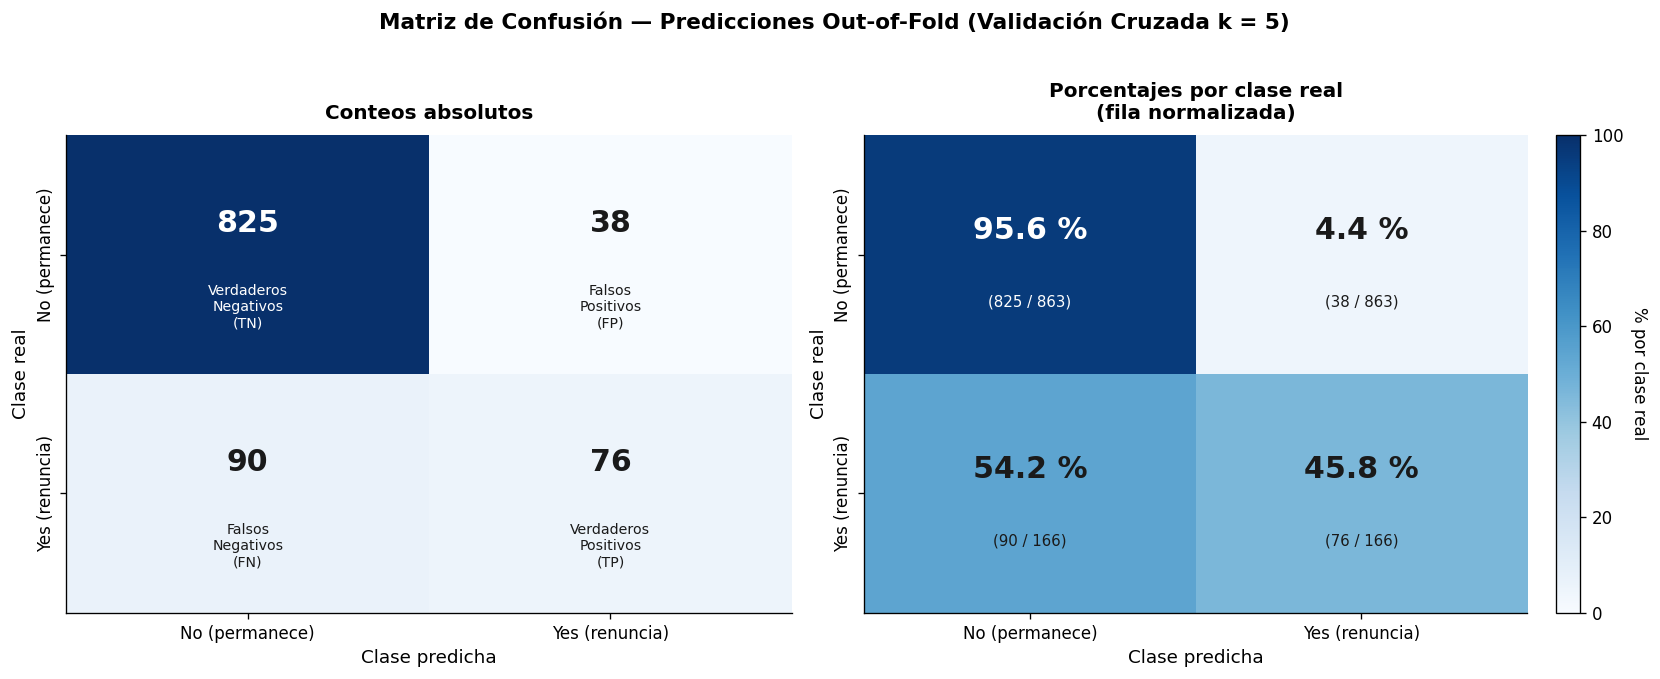

────────────────────────────────────────────────────────────
  Verdaderos Negativos (TN) :   825    — correctamente identificados como 'No'
  Falsos Positivos     (FP) :    38    — falsamente alertados como 'Yes'
  Falsos Negativos     (FN) :    90    — renuncias NO detectadas
  Verdaderos Positivos (TP) :    76    — renuncias correctamente detectadas
────────────────────────────────────────────────────────────
  Sensibilidad (Recall sobre Yes) : 0.4578
  Especificidad (Recall sobre No) : 0.9560
  Precisión (sobre Yes)           : 0.6667
────────────────────────────────────────────────────────────


In [15]:
from sklearn.metrics import confusion_matrix

# Predicciones out-of-fold sobre el conjunto de entrenamiento
y_pred_cv = cross_val_predict(modelo, X_train, y_train, cv=skf, n_jobs=-1)

cm = confusion_matrix(y_train, y_pred_cv, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# Cálculos derivados — porcentajes por fila (sensibilidad por clase real)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

# ── Figura: matriz en conteos y en porcentajes ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

etiquetas = ["No (permanece)", "Yes (renuncia)"]
descripcion = np.array([
    [f"Verdaderos\nNegativos\n(TN)",  f"Falsos\nPositivos\n(FP)"],
    [f"Falsos\nNegativos\n(FN)",       f"Verdaderos\nPositivos\n(TP)"],
])

# ── Panel A: conteos absolutos ───────────────────────────────────────────
ax = axes[0]
im = ax.imshow(cm, cmap="Blues", aspect="auto")
for i in range(2):
    for j in range(2):
        valor = cm[i, j]
        color = "white" if valor > cm.max() * 0.55 else "#1a1a1a"
        ax.text(j, i - 0.13, f"{valor:,}",
                ha="center", va="center",
                color=color, fontsize=18, fontweight="bold")
        ax.text(j, i + 0.22, descripcion[i, j],
                ha="center", va="center", color=color, fontsize=8.5)

ax.set_xticks([0, 1]); ax.set_xticklabels(etiquetas, fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(etiquetas, fontsize=10, rotation=90, va="center")
ax.set_xlabel("Clase predicha", fontsize=11)
ax.set_ylabel("Clase real", fontsize=11)
ax.set_title("Conteos absolutos", fontsize=12, pad=10)

# ── Panel B: porcentajes por clase real (fila normalizada) ───────────────
ax = axes[1]
im = ax.imshow(cm_pct, cmap="Blues", aspect="auto", vmin=0, vmax=100)
for i in range(2):
    for j in range(2):
        valor = cm_pct[i, j]
        color = "white" if valor > 55 else "#1a1a1a"
        ax.text(j, i - 0.10, f"{valor:.1f} %",
                ha="center", va="center",
                color=color, fontsize=18, fontweight="bold")
        ax.text(j, i + 0.20, f"({cm[i, j]:,} / {cm[i].sum():,})",
                ha="center", va="center", color=color, fontsize=9)

ax.set_xticks([0, 1]); ax.set_xticklabels(etiquetas, fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(etiquetas, fontsize=10, rotation=90, va="center")
ax.set_xlabel("Clase predicha", fontsize=11)
ax.set_ylabel("Clase real", fontsize=11)
ax.set_title("Porcentajes por clase real\n(fila normalizada)", fontsize=12, pad=10)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("% por clase real", rotation=270, labelpad=15)

fig.suptitle("Matriz de Confusión — Predicciones Out-of-Fold (Validación Cruzada k = 5)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Resumen numérico ─────────────────────────────────────────────────────
print("─" * 60)
print(f"  Verdaderos Negativos (TN) : {tn:>5,}    — correctamente identificados como 'No'")
print(f"  Falsos Positivos     (FP) : {fp:>5,}    — falsamente alertados como 'Yes'")
print(f"  Falsos Negativos     (FN) : {fn:>5,}    — renuncias NO detectadas")
print(f"  Verdaderos Positivos (TP) : {tp:>5,}    — renuncias correctamente detectadas")
print("─" * 60)
print(f"  Sensibilidad (Recall sobre Yes) : {tp/(tp+fn):.4f}")
print(f"  Especificidad (Recall sobre No) : {tn/(tn+fp):.4f}")
print(f"  Precisión (sobre Yes)           : {tp/(tp+fp) if (tp+fp)>0 else 0:.4f}")
print("─" * 60)

---
## 6. Persistencia de los resultados de CV

Guardamos los scores por fold y las medias en variables `cv_metrics_<modelo>` para reutilizarlos en el **notebook de comparación final** (`5.Comparacion_Modelos.ipynb`).


In [16]:
cv_metrics = {
    "modelo"  : "XGBoost",
    "metricas": {
        m: {
            "scores": cv_results[f"test_{m}"].tolist(),
            "mu"    : float(cv_results[f"test_{m}"].mean()),
            "sigma" : float(cv_results[f"test_{m}"].std()),
        }
        for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]
    }
}

# Guardamos en JSON para que el notebook de comparación los lea
import json, os
os.makedirs("cv_results", exist_ok=True)
out_path = os.path.join("cv_results", "xgboost.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(cv_metrics, f, indent=2, ensure_ascii=False)

print(f"Resultados de CV guardados en: {out_path}")

Resultados de CV guardados en: cv_results/xgboost.json


---
## 7. Síntesis del modelo XGBoost

A partir de la validación cruzada $k=5$ obtenemos un perfil **estable** del comportamiento esperado del modelo:

- Las **cinco métricas** se reportan como $\mu \pm \sigma$ sobre los folds — la columna `Validación` en la tabla 5.2 es la lectura honesta del desempeño esperado en datos nuevos.
- El **gap Train − Validación** (última columna) cuantifica el **sobreajuste**: valores cercanos a cero indican buena generalización; valores positivos grandes (>0.05–0.10) sugieren que el modelo memoriza el entrenamiento.
- La **curva ROC promedio** con su franja $\pm 1\sigma$ resume la capacidad discriminativa global.

> El análisis comparativo entre los cuatro modelos y la elección del mejor se realiza en `5.Comparacion_Modelos.ipynb`.
